Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Dataset

In [2]:
df = pd.read_csv("dataset/Chocolate Sales (2).csv")
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397


Data Understanding

In [3]:
print("First 5 rows of the DataFrame:")
df.head()

First 5 rows of the DataFrame:


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [4]:
print("DataFrame Information:")
df.info()

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


Data Preprocessing

In [5]:
# Missing values
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


In [6]:
# Duplicate values
duplicate_values = df.duplicated().sum()
print("Duplicate Values in the DataFrame:")
print(duplicate_values) 

Duplicate Values in the DataFrame:
0


In [7]:
# Change the data type of 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
print("Data types after converting 'Date' column:")
print(df.dtypes)

Data types after converting 'Date' column:
Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                   object
Boxes Shipped             int64
dtype: object


In [8]:
# Removed currency symbols and separators from 'Amount' column
df['Amount'] = df['Amount'].str.replace('[$,]', '', regex=True).astype(float)
print("Data types after processing 'Amount' column:")
print(df.dtypes)

Data types after processing 'Amount' column:
Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
dtype: object


Exploratory Data Analysis

In [9]:
# Describe the dataset to get a statistical summary of the numerical columns
df.describe()

,Date,Amount,Boxes Shipped
count,3282,3282.000000,3282.000000
mean,2023-05-03 15:09:06.252284928,6030.338775,164.666971
min,2022-01-03 00:00:00,7.000000,1.000000
25%,2022-07-04 00:00:00,2521.495000,71.000000
50%,2023-05-11 00:00:00,5225.500000,137.000000
75%,2024-03-02 00:00:00,8556.842500,232.000000
max,2024-08-31 00:00:00,26170.950000,778.000000
std,NaN,4393.980200,124.024736


In [10]:
# List all the products and their counts in the dataset
print("Products and their Counts in the Dataset:")
df['Product'].value_counts()

Products and their Counts in the Dataset:


Product
Eclairs                 180
50% Dark Bites          180
Smooth Sliky Salty      177
White Choc              174
Drinking Coco           168
Spicy Special Slims     162
Organic Choco Syrup     156
85% Dark Bars           150
Fruit & Nut Bars        150
After Nines             150
Peanut Butter Cubes     147
99% Dark & Pure         147
Milk Bars               147
Raspberry Choco         144
Almond Choco            144
Orange Choco            141
Mint Chip Choco         135
Manuka Honey Choco      135
Caramel Stuffed Bars    129
70% Dark Bites          126
Baker's Choco Chips     123
Choco Coated Almonds    117
Name: count, dtype: int64

In [11]:
# List all countries and their counts in the dataset
print("Countries and their Counts in the Dataset:")
df['Country'].value_counts()

Countries and their Counts in the Dataset:


Country
Australia      615
India          552
USA            537
UK             534
Canada         525
New Zealand    519
Name: count, dtype: int64

In [12]:
# What products are sold the most and least? What is the total amount of sales for each product?
product_sales = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
print("Total sales for each product:")
print(product_sales)

Total sales for each product:
Product
Smooth Sliky Salty      1120201.09
50% Dark Bites          1087659.35
White Choc              1054257.00
Peanut Butter Cubes     1036591.09
Eclairs                  996947.96
99% Dark & Pure          960033.45
85% Dark Bars            955268.24
Organic Choco Syrup      945345.73
Spicy Special Slims      938131.69
Mint Chip Choco          904989.55
Almond Choco             890454.65
Manuka Honey Choco       885208.03
Milk Bars                866273.62
Raspberry Choco          845388.41
After Nines              837215.67
Fruit & Nut Bars         829278.96
Orange Choco             824070.85
Drinking Coco            822245.57
Baker's Choco Chips      799085.67
Choco Coated Almonds     773062.91
Caramel Stuffed Bars     742516.15
70% Dark Bites           677346.22
Name: Amount, dtype: float64


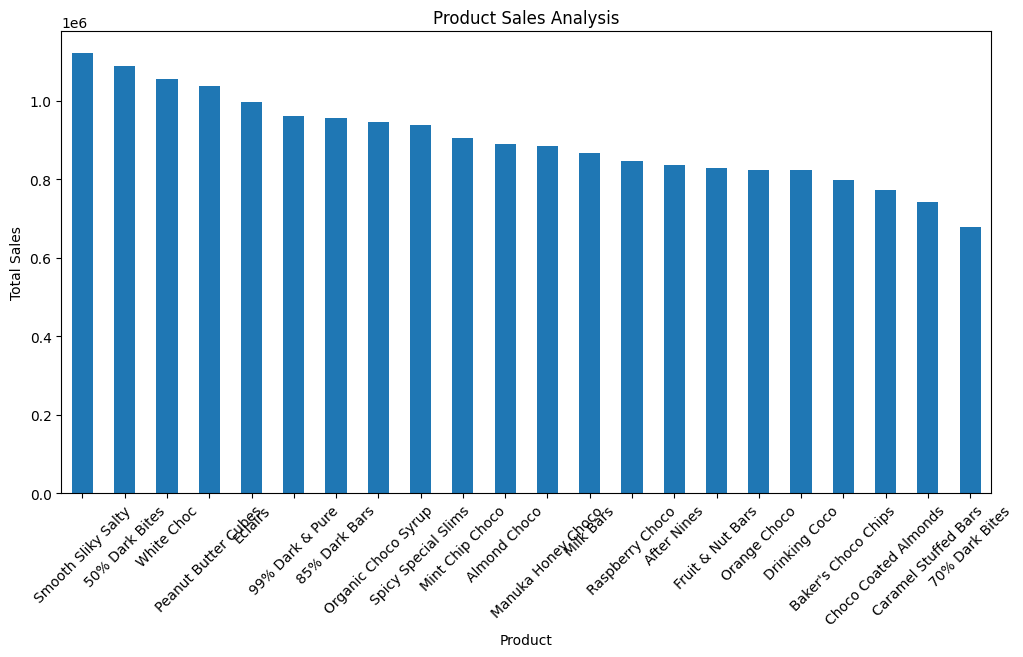

In [13]:
# Visualize the total sales for each product
plt.figure(figsize=(12, 6))
df.groupby('Product')['Amount'].sum().sort_values(ascending=False).plot(kind='bar')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Product Sales Analysis')
plt.xticks(rotation=45)
plt.show()

In [14]:
# Country-wise sales analysis
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
print("Total sales for each country:")
print(country_sales)

Total sales for each country:
Country
Australia      3646444.35
UK             3365388.90
India          3343730.83
USA            3313858.09
Canada         3078495.65
New Zealand    3043654.04
Name: Amount, dtype: float64


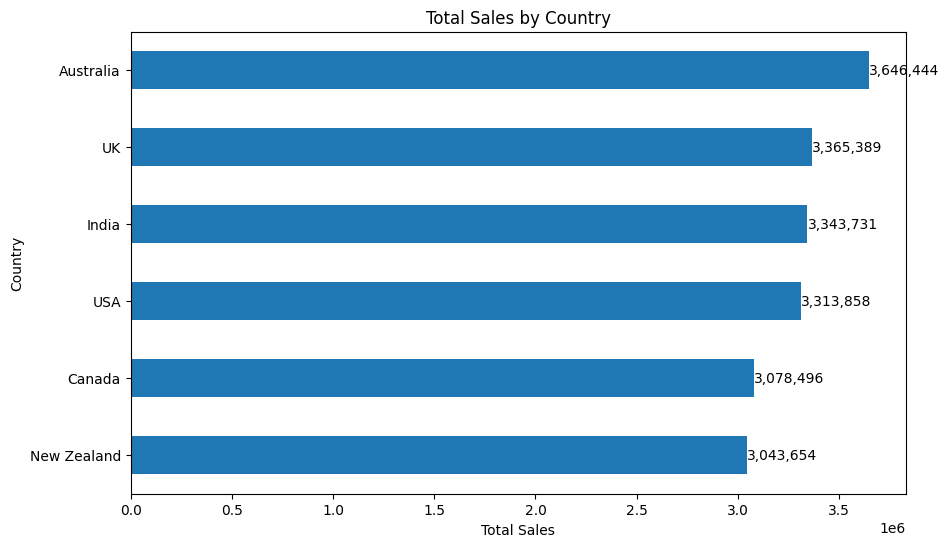

In [15]:
# Visualize the total sales country-wise
plt.figure(figsize=(10, 6))

ax = country_sales.sort_values().plot(kind='barh')

ax.bar_label(ax.containers[0], fmt='{:,.0f}')

plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.title('Total Sales by Country')

plt.show()

In [16]:
# Monthly sales analysis
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Amount'].sum()
print("Total sales for each month:")
print(monthly_sales)

Total sales for each month:
Month
2022-01     896105.00
2022-02     699377.00
2022-03     749483.00
2022-04     674051.00
2022-05     752892.00
2022-06     865144.00
2022-07     803425.00
2022-08     743148.00
2023-01     958985.77
2023-02     749617.46
2023-03     807494.33
2023-04     727743.72
2023-05     811951.78
2023-06     932625.17
2023-07     861856.66
2023-08     793103.07
2024-01    1013621.82
2024-02     783102.44
2024-03     847791.96
2024-04     760132.50
2024-05     850906.79
2024-06     976162.77
2024-07     902250.63
2024-08     830599.99
Freq: M, Name: Amount, dtype: float64


In [58]:
# Total transaction count by month
monthly_transactions_df = (
    df.groupby('Month')['Amount']
      .count()
      .reset_index(name='Transaction Count')
      .sort_values(by='Transaction Count', ascending=False)
)

monthly_transactions_df

,Month,Transaction Count
5,2022-06,163
13,2023-06,163
21,2024-06,163
0,2022-01,154
8,2023-01,154
16,2024-01,154
6,2022-07,149
14,2023-07,149
22,2024-07,149
4,2022-05,135


In [61]:
# Average Transaction Value by Month
monthly_avg_transaction_value_df = (
    df.groupby('Month')['Amount']
      .mean()
      .reset_index(name='Average Transaction Value')
      .sort_values(by='Average Transaction Value', ascending=False)
)

monthly_avg_transaction_value_df

,Month,Average Transaction Value
17,2024-02,7119.113091
9,2023-02,6814.704182
16,2024-01,6581.959870
18,2024-03,6471.694351
19,2024-04,6441.800847
1,2022-02,6357.972727
20,2024-05,6303.013259
8,2023-01,6227.180325
23,2024-08,6198.507388
11,2023-04,6167.319661


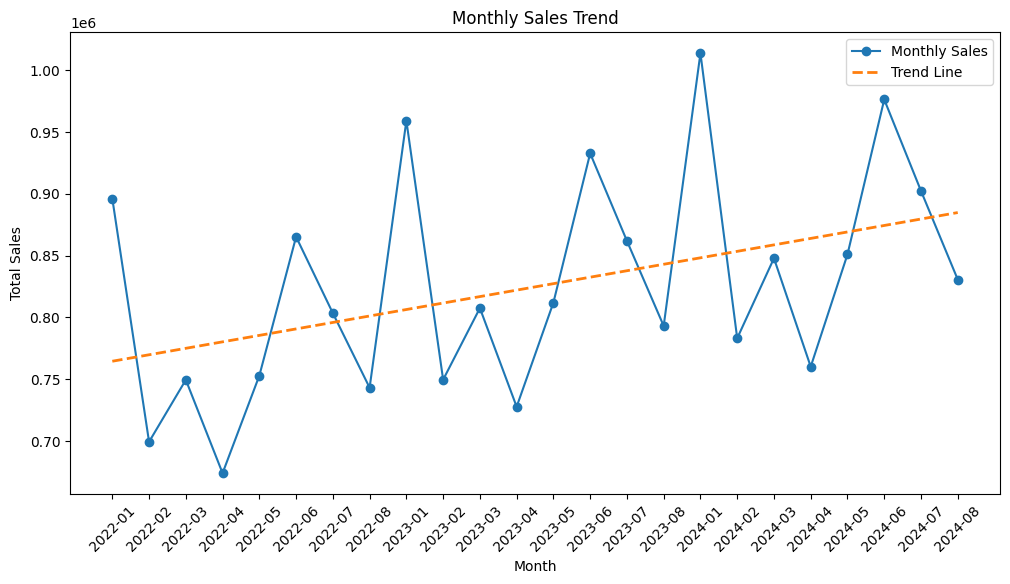

In [17]:
# Visualize monthly sales trend
x = np.arange(len(monthly_sales))
y = monthly_sales.values

# Membuat garis tren linear
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(12, 6))

plt.plot(monthly_sales.index.astype(str), y, marker='o', label='Monthly Sales')
plt.plot(monthly_sales.index.astype(str), p(x), linestyle='--', linewidth=2, label='Trend Line')

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [18]:
# Sales person-wise analysis
salesperson_sales = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)
print("Total sales for each sales person:")
print(salesperson_sales)

Total sales for each sales person:
Sales Person
Ches Bonnell           1022599.96
Oby Sorrel             1017204.12
Madelene Upcott        1010028.72
Kelci Walkden          1002929.10
Brien Boise             997326.48
Van Tuxwell             974425.09
Dennison Crosswaite     931849.57
Beverie Moffet          892421.37
Kaine Padly             849062.76
Marney O'Breen          836427.63
Barr Faughny            830826.91
Roddy Speechley         808359.58
Gunar Cockshoot         762283.43
Gigi Bohling            742296.51
Karlen McCaffrey        713832.64
Jehu Rudeforth          708505.03
Jan Morforth            706585.50
Curtice Advani          691797.92
Rafaelita Blaksland     668865.45
Husein Augar            656149.73
Andria Kimpton          648214.81
Mallorie Waber          642903.33
Camilla Castle          628613.13
Dotty Strutley          608101.17
Wilone O'Kielt          439961.92
Name: Amount, dtype: float64


In [33]:
# Total transaction count for each sales person
transaction_count = df['Sales Person'].value_counts()
transaction_count_df = transaction_count.reset_index()
transaction_count_df.columns = ['Sales Person', 'Transaction Count']
transaction_count_df

,Sales Person,Transaction Count
0,Kelci Walkden,162
1,Brien Boise,159
2,Van Tuxwell,153
3,Beverie Moffet,150
4,Oby Sorrel,147
5,Dennison Crosswaite,147
6,Ches Bonnell,144
7,Gigi Bohling,141
8,Karlen McCaffrey,141
9,Curtice Advani,138


In [34]:
# Total "Boxes Shipped" by each sales person
boxes_shipped = df.groupby('Sales Person')['Boxes Shipped'].sum().sort_values(ascending=False) 
boxes_shipped_df = boxes_shipped.reset_index()
boxes_shipped_df.columns = ['Sales Person', 'Total Boxes Shipped']
boxes_shipped_df

,Sales Person,Total Boxes Shipped
0,Karlen McCaffrey,29553
1,Beverie Moffet,28027
2,Dennison Crosswaite,26862
3,Kelci Walkden,26605
4,Oby Sorrel,26390
5,Brien Boise,24738
6,Marney O'Breen,24595
7,Jan Morforth,23360
8,Ches Bonnell,23070
9,Madelene Upcott,22199


In [43]:
# Sales summary
sales_summary = (
    df.groupby('Sales Person')
      .agg(
          Amount=('Amount', 'sum'),
          Transactions=('Amount', 'count'),
          Boxes_Shipped=('Boxes Shipped', 'sum')
      )
      .sort_values(by='Amount', ascending=False)
)

sales_summary

,Amount,Transactions,Boxes_Shipped
Sales Person,,,
Ches Bonnell,1022599.96,144,23070
Oby Sorrel,1017204.12,147,26390
Madelene Upcott,1010028.72,135,22199
Kelci Walkden,1002929.10,162,26605
Brien Boise,997326.48,159,24738
Van Tuxwell,974425.09,153,20627
Dennison Crosswaite,931849.57,147,26862
Beverie Moffet,892421.37,150,28027
Kaine Padly,849062.76,135,22134


In [54]:
# Average Revenue per Transaction
avg_df = (
    sales_summary['Amount']
    .div(sales_summary['Transactions'])
    .reset_index(name='Average Revenue per Transaction')
)

avg_df.sort_values(by='Average Revenue per Transaction', ascending=False)


,Sales Person,Average Revenue per Transaction
2,Madelene Upcott,7481.694222
0,Ches Bonnell,7101.388611
1,Oby Sorrel,6919.755918
18,Rafaelita Blaksland,6557.504412
22,Camilla Castle,6548.053437
10,Barr Faughny,6440.518682
5,Van Tuxwell,6368.791438
6,Dennison Crosswaite,6339.112721
8,Kaine Padly,6289.353778
4,Brien Boise,6272.493585


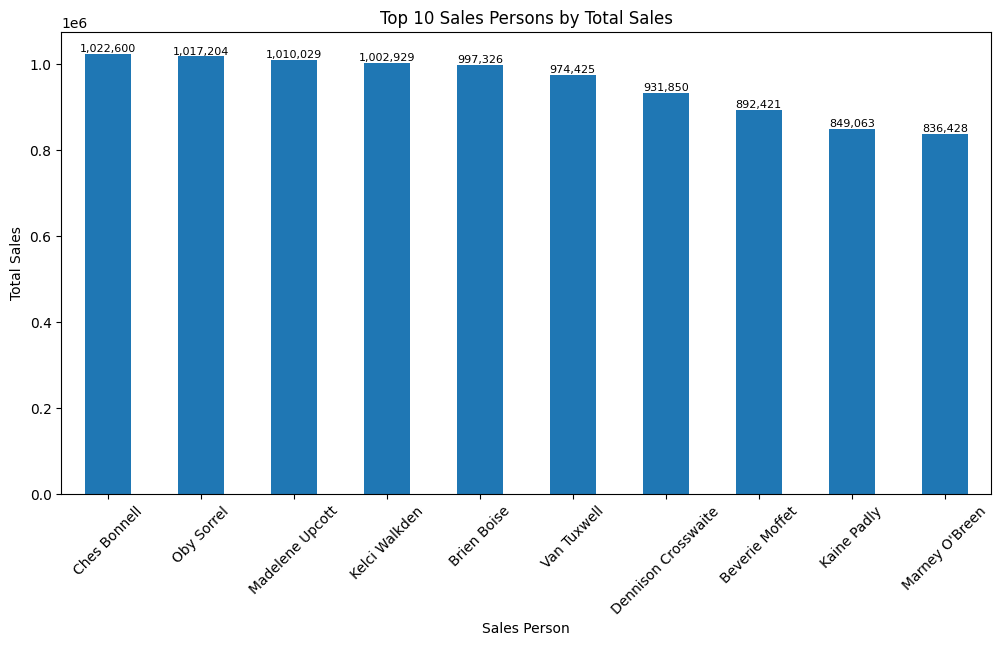

In [19]:
# Visualize sales person-wise analysis
top10_salesperson = (
    df.groupby('Sales Person')['Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

ax = top10_salesperson.plot(kind='bar', figsize=(12, 6))

ax.bar_label(ax.containers[0], fmt='{:,.0f}', fontsize=8)

plt.xlabel('Sales Person')
plt.ylabel('Total Sales')
plt.title('Top 10 Sales Persons by Total Sales')
plt.xticks(rotation=45)

plt.show()

In [20]:
# Top 5 products with the highest sales
top_5_products = product_sales.head(5) 
print("Top 5 products with the highest sales:")
print(top_5_products)

Top 5 products with the highest sales:
Product
Smooth Sliky Salty     1120201.09
50% Dark Bites         1087659.35
White Choc             1054257.00
Peanut Butter Cubes    1036591.09
Eclairs                 996947.96
Name: Amount, dtype: float64


In [25]:
# Top 5 products with the highest sales in Australia
australia_sales = df[df['Country'] == 'Australia']
top_5_australia_products = australia_sales.groupby('Product')['Amount'].sum().nlargest(5)
top_5_australia_products

Product
50% Dark Bites         280066.82
Eclairs                208469.73
Milk Bars              197947.30
Spicy Special Slims    196749.40
Organic Choco Syrup    196655.35
Name: Amount, dtype: float64

In [29]:
# Country with the highest sales of "Smooth Sliky Salty"
smooth_sliky_salty_sales = df[df['Product'] == 'Smooth Sliky Salty']
top_country_smooth_sliky_salty = smooth_sliky_salty_sales.groupby('Country')['Amount'].sum().sort_values(ascending=False)
top_country_smooth_sliky_salty

Country
UK             244456.77
India          241770.37
Canada         218122.40
Australia      145313.04
USA            144840.22
New Zealand    125698.29
Name: Amount, dtype: float64

In [32]:
# Top 5 products with the highest sales in each country
top_5_products_by_country = (
    df.groupby(['Country', 'Product'], as_index=False)['Amount']
      .sum()
      .groupby('Country', group_keys=False)
      .apply(lambda x: x.nlargest(5, 'Amount'))
      .reset_index(drop=True)
)

top_5_products_by_country

C:\Users\Adisah\AppData\Local\Temp\ipykernel_9316\2644184160.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'Amount'))


,Country,Product,Amount
0,Australia,50% Dark Bites,280066.82
1,Australia,Eclairs,208469.73
2,Australia,Milk Bars,197947.30
3,Australia,Spicy Special Slims,196749.40
4,Australia,Organic Choco Syrup,196655.35
5,Canada,Smooth Sliky Salty,218122.40
6,Canada,Peanut Butter Cubes,199711.92
7,Canada,70% Dark Bites,189698.51
8,Canada,Spicy Special Slims,185301.81
9,Canada,Choco Coated Almonds,183459.19
